In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import colormaps as cm
import csv
from pathlib import Path
import glob
import seaborn as sns

In [2]:
def load_drive(E=1.0, smooth=100):
    if E == -1:
        fJ = lambda x: x * (1- np.exp(-smooth * x * x))
        fg = lambda x: 3.04438 * (1 - fJ(x))
    elif E == -2:
        fJ = lambda x: x * (1- np.exp(-32 * x))
        fg = lambda x: 3.04438 * (1 - fJ(x))
    elif E == -3:
        fJ = lambda x: 0.5 + 1.5 * (x - 0.5) - 2 * (x - 0.5) ** 3
        fg = lambda x: 3.04438 * (1 - fJ(x))
    elif E == -4:
        fJ = lambda x: x ** 2
        fg = lambda x: (1 - x) ** 2
    elif E == -5:
        fJ = lambda x: 1 - np.exp(-smooth * x * x)
        fg = lambda x: 3.04438 * 2 * (1 - x * fJ(x))
    else:
        schedule = np.loadtxt('09-1265A-E_Advantage_system5_4_annealing_schedule.csv', delimiter=",")
        fg = scipy.interpolate.UnivariateSpline(schedule[:, 0], schedule[:, 1] * np.pi * (1 - np.exp(-smooth * schedule[:, 0]**2)) + np.exp(-smooth * schedule[:, 0]**2) * 30, s=0, k=4)
        fJ = scipy.interpolate.UnivariateSpline(schedule[:, 0], schedule[:, 2] * E * np.pi * (1 - np.exp(-smooth * schedule[:, 0]**2)), s=0, k=4)
    return fg, fJ

def get_sc(E):
    gc = 3.04438
    fg, fJ = load_drive(E)
    sc = scipy.optimize.fsolve(lambda s: fg(s) - gc * fJ(s), 0.5)
    return sc[0]

Eset = [-2]

In [3]:
print("E, dg, dJ, ff")
for E in [1.0, 0.5, -1, -2, -3, -4, -5]:
    sc = get_sc(E)
    ds = 0.001
    fg, fJ = load_drive(E)
    dg = ((fg(sc + ds) - fg(sc)) / ds) / fg(sc)
    dJ = ((fJ(sc + ds) - fJ(sc)) / ds) / fJ(sc)
    ff = fg(sc) / (dJ - dg)
    print(f"{E=:0.2f}, {dg=:0.2f}, {dJ=:0.2f}, {ff=:0.5f}, {4 * ff=:0.5f}")

E, dg, dJ, ff
E=1.00, dg=-10.11, dJ=8.57, ff=0.44917, 4 * ff=1.79670
E=0.50, dg=-13.58, dJ=9.53, ff=0.24426, 4 * ff=0.97705
E=-1.00, dg=-2.00, dJ=2.00, ff=0.38055, 4 * ff=1.52219
E=-2.00, dg=-2.00, dJ=2.00, ff=0.38055, 4 * ff=1.52219
E=-3.00, dg=-3.00, dJ=3.00, ff=0.25370, 4 * ff=1.01479
E=-4.00, dg=-3.14, dJ=5.50, ff=0.04676, 4 * ff=0.18706
E=-5.00, dg=-2.00, dJ=0.00, ff=1.52219, 4 * ff=6.08876


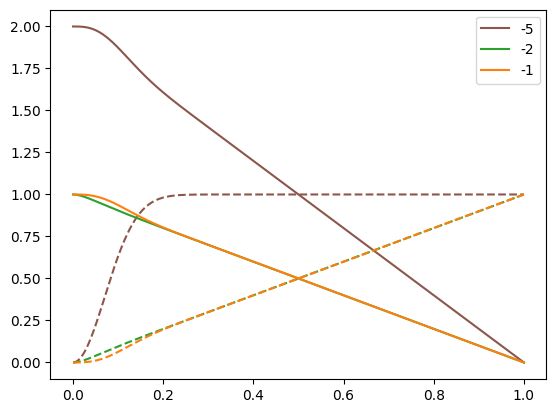

In [4]:
gc = 3.04438
gg, JJ = {}, {}

for n in range(-5, 0):
    gg[n], JJ[n] = load_drive(n)


for n in [-5, -2, -1]:
    x = np.linspace(0, 1, 1001)
    plt.plot(x, gg[n](x) / gc, '-', label=str(n), color = plt.cm.tab10(-n))
    plt.plot(x, JJ[n](x), '--', color = plt.cm.tab10(-n))
plt.legend()


In [5]:
data = {}

for fname in glob.glob("./bias_dwave/**/data*.csv", recursive=True):
    param = fname.split("/")
    hz = float(param[2][3:])
    ta = float(param[3][3:])
    bb = param[5]
    E = float(param[4][2:])
    fieldnames = ["D", "which", "chi", "dt", "Delta", "time", "Ezz", "Ez", "Ex"]
    dtypes =     [int, str, int, float, float, float, float, float, float]
    sf = float(param[6][8:14])
    ind = (hz, ta, E, sf, bb)

    if E in Eset:

        with open(fname, 'r', newline='') as csvfile:
            csvfile.readline()
            data[ind] = []
            for x in csv.DictReader(csvfile, fieldnames=fieldnames, delimiter=";"):
                for fn, typ in zip(fieldnames, dtypes):
                    x[fn] = typ(x[fn])
                x["Eng"] = (-2 * x["Ezz"] - float(hz) * x["Ez"])
                data[ind].append(x)

In [6]:
def get_sf(hz, ta, E):
    sfs = []
    for ind in data:
        #print(ind[:3], (hz, ta, E))
        if ind[:3] == (hz, ta, E):
            sfs.append(ind[3])
    sfs.sort()
    return sfs

In [7]:
smpls = {}

for fname in glob.glob("./bias_dwave/**/sample*.npy", recursive=True):
    param = fname.split("/")
    param = fname.split("/")
    hz = float(param[2][3:])
    ta = float(param[3][3:])
    bb = param[5]
    E = float(param[4][2:])
    nn = param[6].split("_")
    D = int(nn[1][2:])
    chi = int(nn[2][4:])
    if len(nn) == 5:
        sf = float(nn[4][3:-4])
        ind = (hz, ta, E, sf, D, chi, '16x16')
    else:
        sf = float(nn[4][3:])
        xy = nn[5][:-4]
        ind = (hz, ta, E, sf, D, chi, xy)
    if E in Eset:
        smpls[ind] = np.load(fname, allow_pickle=True)


In [8]:
data_zz = {}
for fname in glob.glob("./bias_dwave/**/Ezzs*.csv", recursive=True):
    param = fname.split("/")
    hz = float(param[2][3:])
    ta = float(param[3][3:])
    E = float(param[4][2:])
    bb = param[5]
    sf = float(param[6][8:14])
    ind = (hz, ta, E, sf, bb)
    if E in Eset:
        with open(fname, 'r', newline='') as csvfile:
            for row in csv.DictReader(csvfile, delimiter=';'):
                if None in row:
                    row.pop(None)
                for k, v in row.items():
                    if k in ["D", 'chi']:
                        row[k] = int(v)
                    elif k is not None and 'Ezz' in k:
                        row[k] = float(v)

                aa = {int(k[4:]): v for k, v in row.items() if 'Ezz_' in k}
                aa = dict(sorted(aa.items()))
                if (row['D'], row['which'], row['chi']) == (8, 'NN+BP', 16):
                    if ind not in data_zz:
                        data_zz[ind] = list(aa.values())
                if (row['D'], row['which'], row['chi']) == (16, 'NN+BP', 16):
                    data_zz[ind] = list(aa.values())


In [9]:
four = {}
for fname in glob.glob("./bias_dwave/**/env_*.npy", recursive=True):
    try:
        param = fname.split("/")
        hz = float(param[2][3:])
        ta = float(param[3][3:])
        bb = param[5]
        E = float(param[4][2:])
        nn = param[6].split("_")
        D = int(nn[1][2:])
        chi = int(nn[2][4:])
        sf = float(nn[4][3:-4])
        ind = (hz, ta, E, sf, D)
        if E in Eset:
            d = np.load(fname, allow_pickle=True).item()
            four[ind] = d['four']
    except:
        pass

In [24]:
def plot_ax(ax, hz, E, val='Ezz', bb='ZZ', in_g=False):
    Dline = {8: ':', 12:'--', 16: "-.", 20: "-"}
    gc = 3.04438
    cm = plt.cm.jet
    tas = 2 ** np.linspace(0, 4, 33)
    tas = [float(f"{x:0.4f}") for x in tas]
    # tas = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 5.4, 6.3, 7.2, 8.0, 16.0] #, 8.0, 8.3, 9.6, 16.0, 32.0, 64.0]
    sc = get_sc(E)

    fg, fJ = load_drive(E, smooth=100)

    for ii, ta in enumerate(tas):
        sfs = get_sf(hz, ta, E)
        dat = {}
        for sf in sfs:
            if (hz, ta, E, sf, bb) in data:
                unique_D = []
                for x in data[hz, ta, E, sf, bb]:
                    if x['D'] not in unique_D:
                        unique_D.append(x['D'])
                        if x['D'] in dat:
                            dat[x['D']].append(x[val])
                        else:
                            dat[x['D']] = [x[val]]
        sff = [float(sf) for sf in sfs]
        v8 = np.abs(dat[8])
        v12 = np.abs(dat[12])
        ll = min(len(v8), len(v12))
        v8 = v8[:ll]
        v12 = v12[:ll]
        sss = np.array(sff[:ll])
        ind, = np.where(np.abs(((v12 - v8) / v12)) > 0.01)
        if len(ind) > 0:
            ind = ind[0]
        else:
            ind = ll
        v12 = v12[:ind]
        sss = sss[:ind]
        line, = ax.plot(sss, v12, color=cm(ii / len(tas)))  # Dline[k],
        if int(ta) == ta:
            line.set_label(f"{ta=}")

        # for k, v in dat.items():
        #     if k in [8, 12, 16]:
        #         sss = np.array(sff[:len(v)])
        #         if in_g:
        #             sss = fg(sss) /  (fJ(sss) * gc)
        #         line, = ax.plot(sss, np.abs(v), Dline[k], color=cm(ii / len(tas)))
        #         if k == 8 and int(ta) == ta:
        #             line.set_label(f"{ta=}")
    #ax.axvline(x=0.4, linestyle=':', color='k')

    ax.set_ylabel(val)
    ax.set_title(f"{hz=} {E=}")
    ax.set_ylim([0, 1.0])
    if in_g:
        ax.set_xlim([0, 2])
        ax.axvline(x=1, linestyle=':', color='k')
        ax.set_xlabel("g / (gc J)")
    else:
        ax.set_xlabel("s")
        ax.axvline(x=sc, linestyle=':', color='k')
        if E < 0:
            ax.set_xlim([0, 1.0])
        else:
            ax.set_xlim([0, 0.6])


In [36]:
def plot_4point(ax, hz, E, D = 12, val= ((1, 1), (1, 1)), bb='ZZ', in_g=False):
    Dline = {8: ':', 12:'--', 16: "-.", 20: "-"}
    gc = 3.04438
    cm = plt.cm.jet

    tas = 2 ** np.linspace(0, 4, 33)
    tas = [float(f"{x:0.4f}") for x in tas]

    sc = get_sc(E)

    fg, fJ = load_drive(E, smooth=100)

    for ii, ta in enumerate(tas):
        sfs = get_sf(hz, ta, E)
        sfs = [float(sf) for sf in sfs]


        # v = [four[(hz, ta, E, sf, D)][val] for sf in sfs if (hz, ta, E, sf, D) in four]

        v8 = [four[(hz, ta, E, sf, 8)][val] for sf in sfs if (hz, ta, E, sf, D) in four]
        v12 = [four[(hz, ta, E, sf, 12)][val] for sf in sfs if (hz, ta, E, sf, D) in four]

        ll = min(len(v8), len(v12))
        v8 = np.array(v8[:ll])
        v12 = np.array(v12[:ll])
        sss = np.array(sfs[:ll])
        ind, = np.where(np.abs(((v12 - v8) / v12)) > 0.01)
        if len(ind) > 0:
            ind = ind[0]
        else:
            ind = ll
        v12 = v12[:ind]
        sss = sss[:ind]
        if in_g:
            sss = fg(sss) /  (fJ(sss) * gc)
        # v = np.abs(v)
        line, = ax.plot(sss, v12, color=cm(ii / len(tas)))
        if int(ta) == ta:
            line.set_label(f"{ta=}")

    ax.set_ylabel(val)
    ax.set_title(f"{hz=} {E=}")
    # ax.set_ylim([0, 1.0])
    if in_g:
        ax.set_xlim([0, 2])
        ax.axvline(x=1, linestyle=':', color='k')
        ax.set_xlabel("g / (gc J)")
    else:
        ax.set_xlabel("s")
        ax.axvline(x=sc, linestyle=':', color='k')
        if E < 0:
            ax.set_xlim([0, 1.0])
        else:
            ax.set_xlim([0, 0.6])


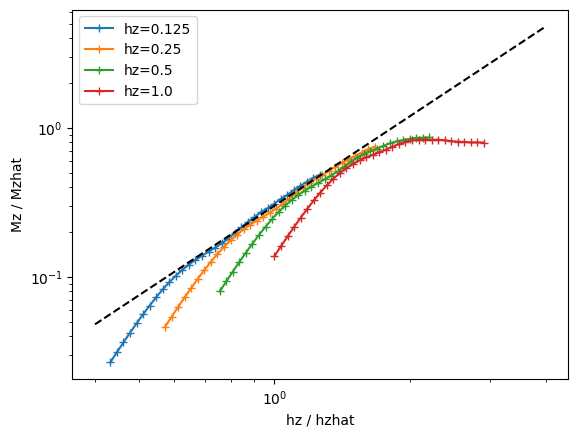

In [13]:
E = -2
sf = 0.5
bb = 'ZZ'
tas = 2 ** np.linspace(0, 4, 33)
tas = [float(f"{x:0.4f}") for x in tas]

for hz in [0.125, 0.25, 0.5, 1.0]:
    xx, yy = [], []
    for ta in tas:
        Ez = max(data[(hz, ta, E, sf, bb)], key= lambda x: (x['D'], len(x['which'])))['Ez']

        xx.append(ta ** 0.386 * hz ** 0.403)
        yy.append(Ez / hz ** (0.208))

        # hzhat = ta ** -0.959
        # Mzhat = hzhat ** 0.209
        # xx.append(hz / hzhat)
        # yy.append(Ez / Mzhat)
    plt.loglog(xx, yy, '-+', label=f"{hz=}")
plt.legend()
plt.xlabel('hz / hzhat')
plt.ylabel('Mz / Mzhat')
plt.loglog([0.4, 4], [0.3 * 0.4**2, 0.3*4**2], '--k')

In [14]:
tas = 2 ** np.linspace(0-1, 4, 41)
xihat = tas ** 0.3865
hzhat = tas ** -0.959
Mzhat = hzhat ** 0.209
#  xi_z = h_z ** -0.403
#  M_z = h_z ** 0.209
#  M_z = xi_z ** -0.518  == xi ** -Delta_z
print(f"{tas=}")
print(f"{xihat=}")
print(f"{hzhat=}")


tas=array([ 0.5       ,  0.54525387,  0.59460356,  0.64841978,  0.70710678,
        0.77110541,  0.84089642,  0.91700404,  1.        ,  1.09050773,
        1.18920712,  1.29683955,  1.41421356,  1.54221083,  1.68179283,
        1.83400809,  2.        ,  2.18101547,  2.37841423,  2.59367911,
        2.82842712,  3.08442165,  3.36358566,  3.66801617,  4.        ,
        4.36203093,  4.75682846,  5.18735822,  5.65685425,  6.1688433 ,
        6.72717132,  7.33603235,  8.        ,  8.72406186,  9.51365692,
       10.37471644, 11.3137085 , 12.3376866 , 13.45434264, 14.67206469,
       16.        ])
xihat=array([0.76498322, 0.79103449, 0.81797293, 0.84582875, 0.87463319,
       0.90441856, 0.93521826, 0.96706683, 1.        , 1.0340547 ,
       1.06926912, 1.10568275, 1.14333644, 1.18227242, 1.22253435,
       1.26416739, 1.30721822, 1.35173514, 1.39776807, 1.44536864,
       1.49459023, 1.54548805, 1.59811918, 1.65254264, 1.70881948,
       1.76701281, 1.8271879 , 1.88941223, 1.95375559, 2.0

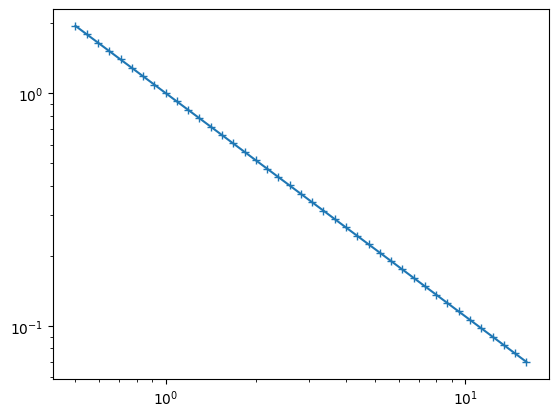

In [15]:
plt.loglog(tas, hzhat, '-+')

In [16]:
def plot_zz(ax, hz = 0.0, tt = 0.0, rescale=True):


    kzexp = 0.3865

    cm = plt.cm.jet
    tas = [float(f"{x:0.4f}") for x in 2 ** np.linspace(0, 4, 33)]
    sc = 0.5
    E = -2.0
    for i, ta in enumerate(tas):
        tQ = 0.38054690140 * ta
        that = xi = tQ ** kzexp
        ss = sc + tt * that / ta
        s0 = np.floor(100 * ss) / 100
        s1 = np.ceil(100 * ss) / 100
        try:
            ind0 = (hz, ta, E, s0, 'ZZ')
            ind1 = (hz, ta, E, s1, 'ZZ')
            v0 = np.array(data_zz[ind0])
            v1 = np.array(data_zz[ind1])
            if s1 > s0:
                v = v0 * (s1 - ss) / (s1 - s0) + v1 * (ss - s0) / (s1 - s0)
            else:
                v = v0
            v = v - v[-1]
            r = np.arange(20) + 1
            if rescale:
                line, = ax.semilogy(r / xi, np.abs(v) * xi ** 1.036, '+', color=cm(i / len(tas)))
            else:
                line, = ax.semilogy(r, np.abs(v), '+', color=cm(i / len(tas)))

            if int(ta) == ta:
                line.set_label(f"{ta=}")
            #
        except KeyError:
            pass
    ax.legend()
    if rescale:
        ax.set_xlabel('r / xi')
        ax.set_ylabel('C(r) * xi^1.036')
        ax.set_xlim([0, 5])
        ax.set_ylim([1e-4, 1])
    else:
        ax.set_xlabel('r')
        ax.set_ylabel('C(r)')
        ax.set_xlim([0, 10])
        ax.set_ylim([1e-6, 1])
    ax.set_title(f"{hz=} t/that={tt}")


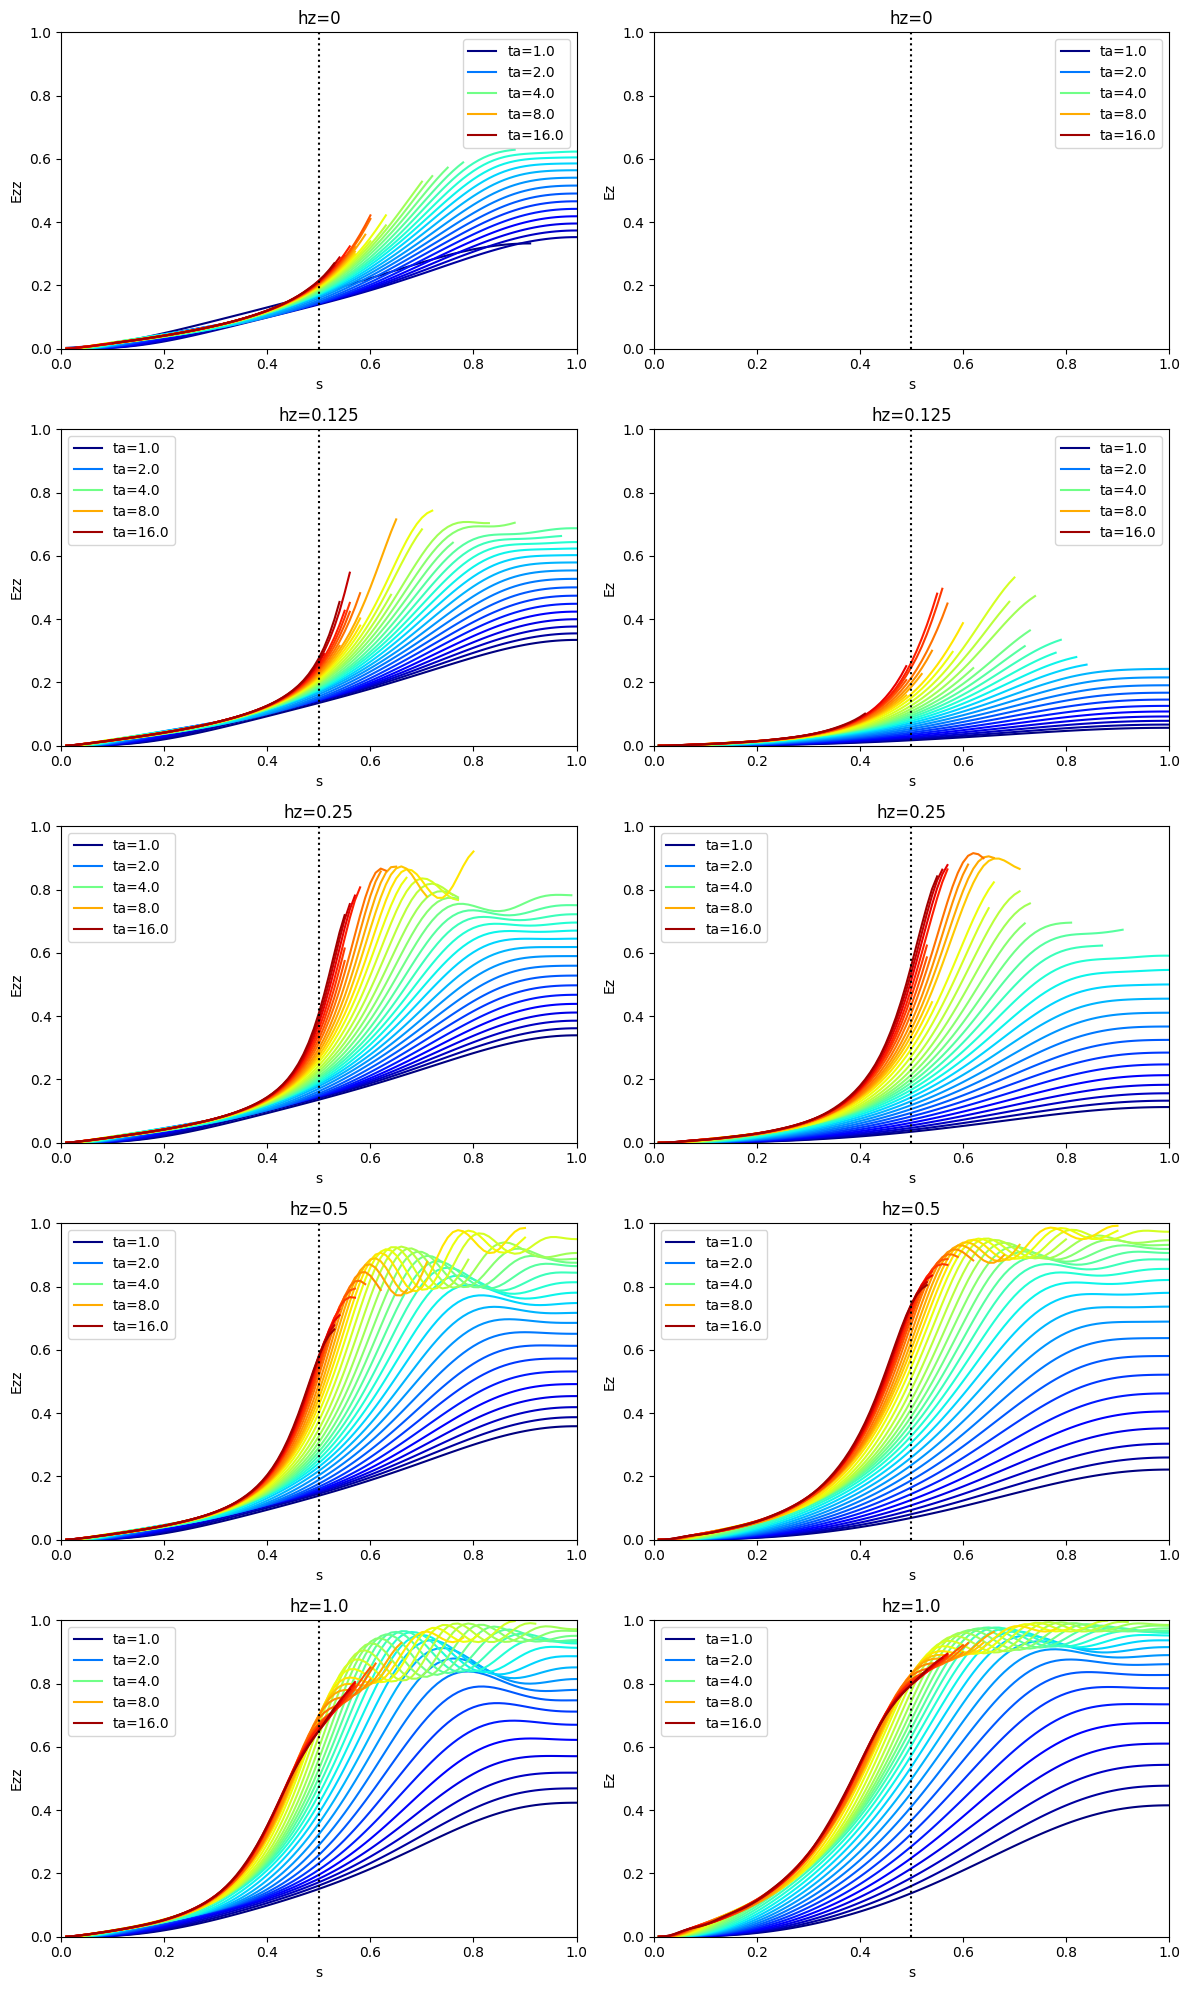

In [29]:
fig, axs = plt.subplots(5, 2)
fig.set_size_inches(12, 20)

for ii, hz in enumerate([0, 0.125, 0.25, 0.5, 1.0]):
    for jj, val in enumerate(['Ezz', 'Ez']):
        plot_ax(axs[ii, jj], hz=hz, E=-2, val=val)
        axs[ii, jj].legend()
        axs[ii, jj].set_title(f"{hz=}")
fig.tight_layout()


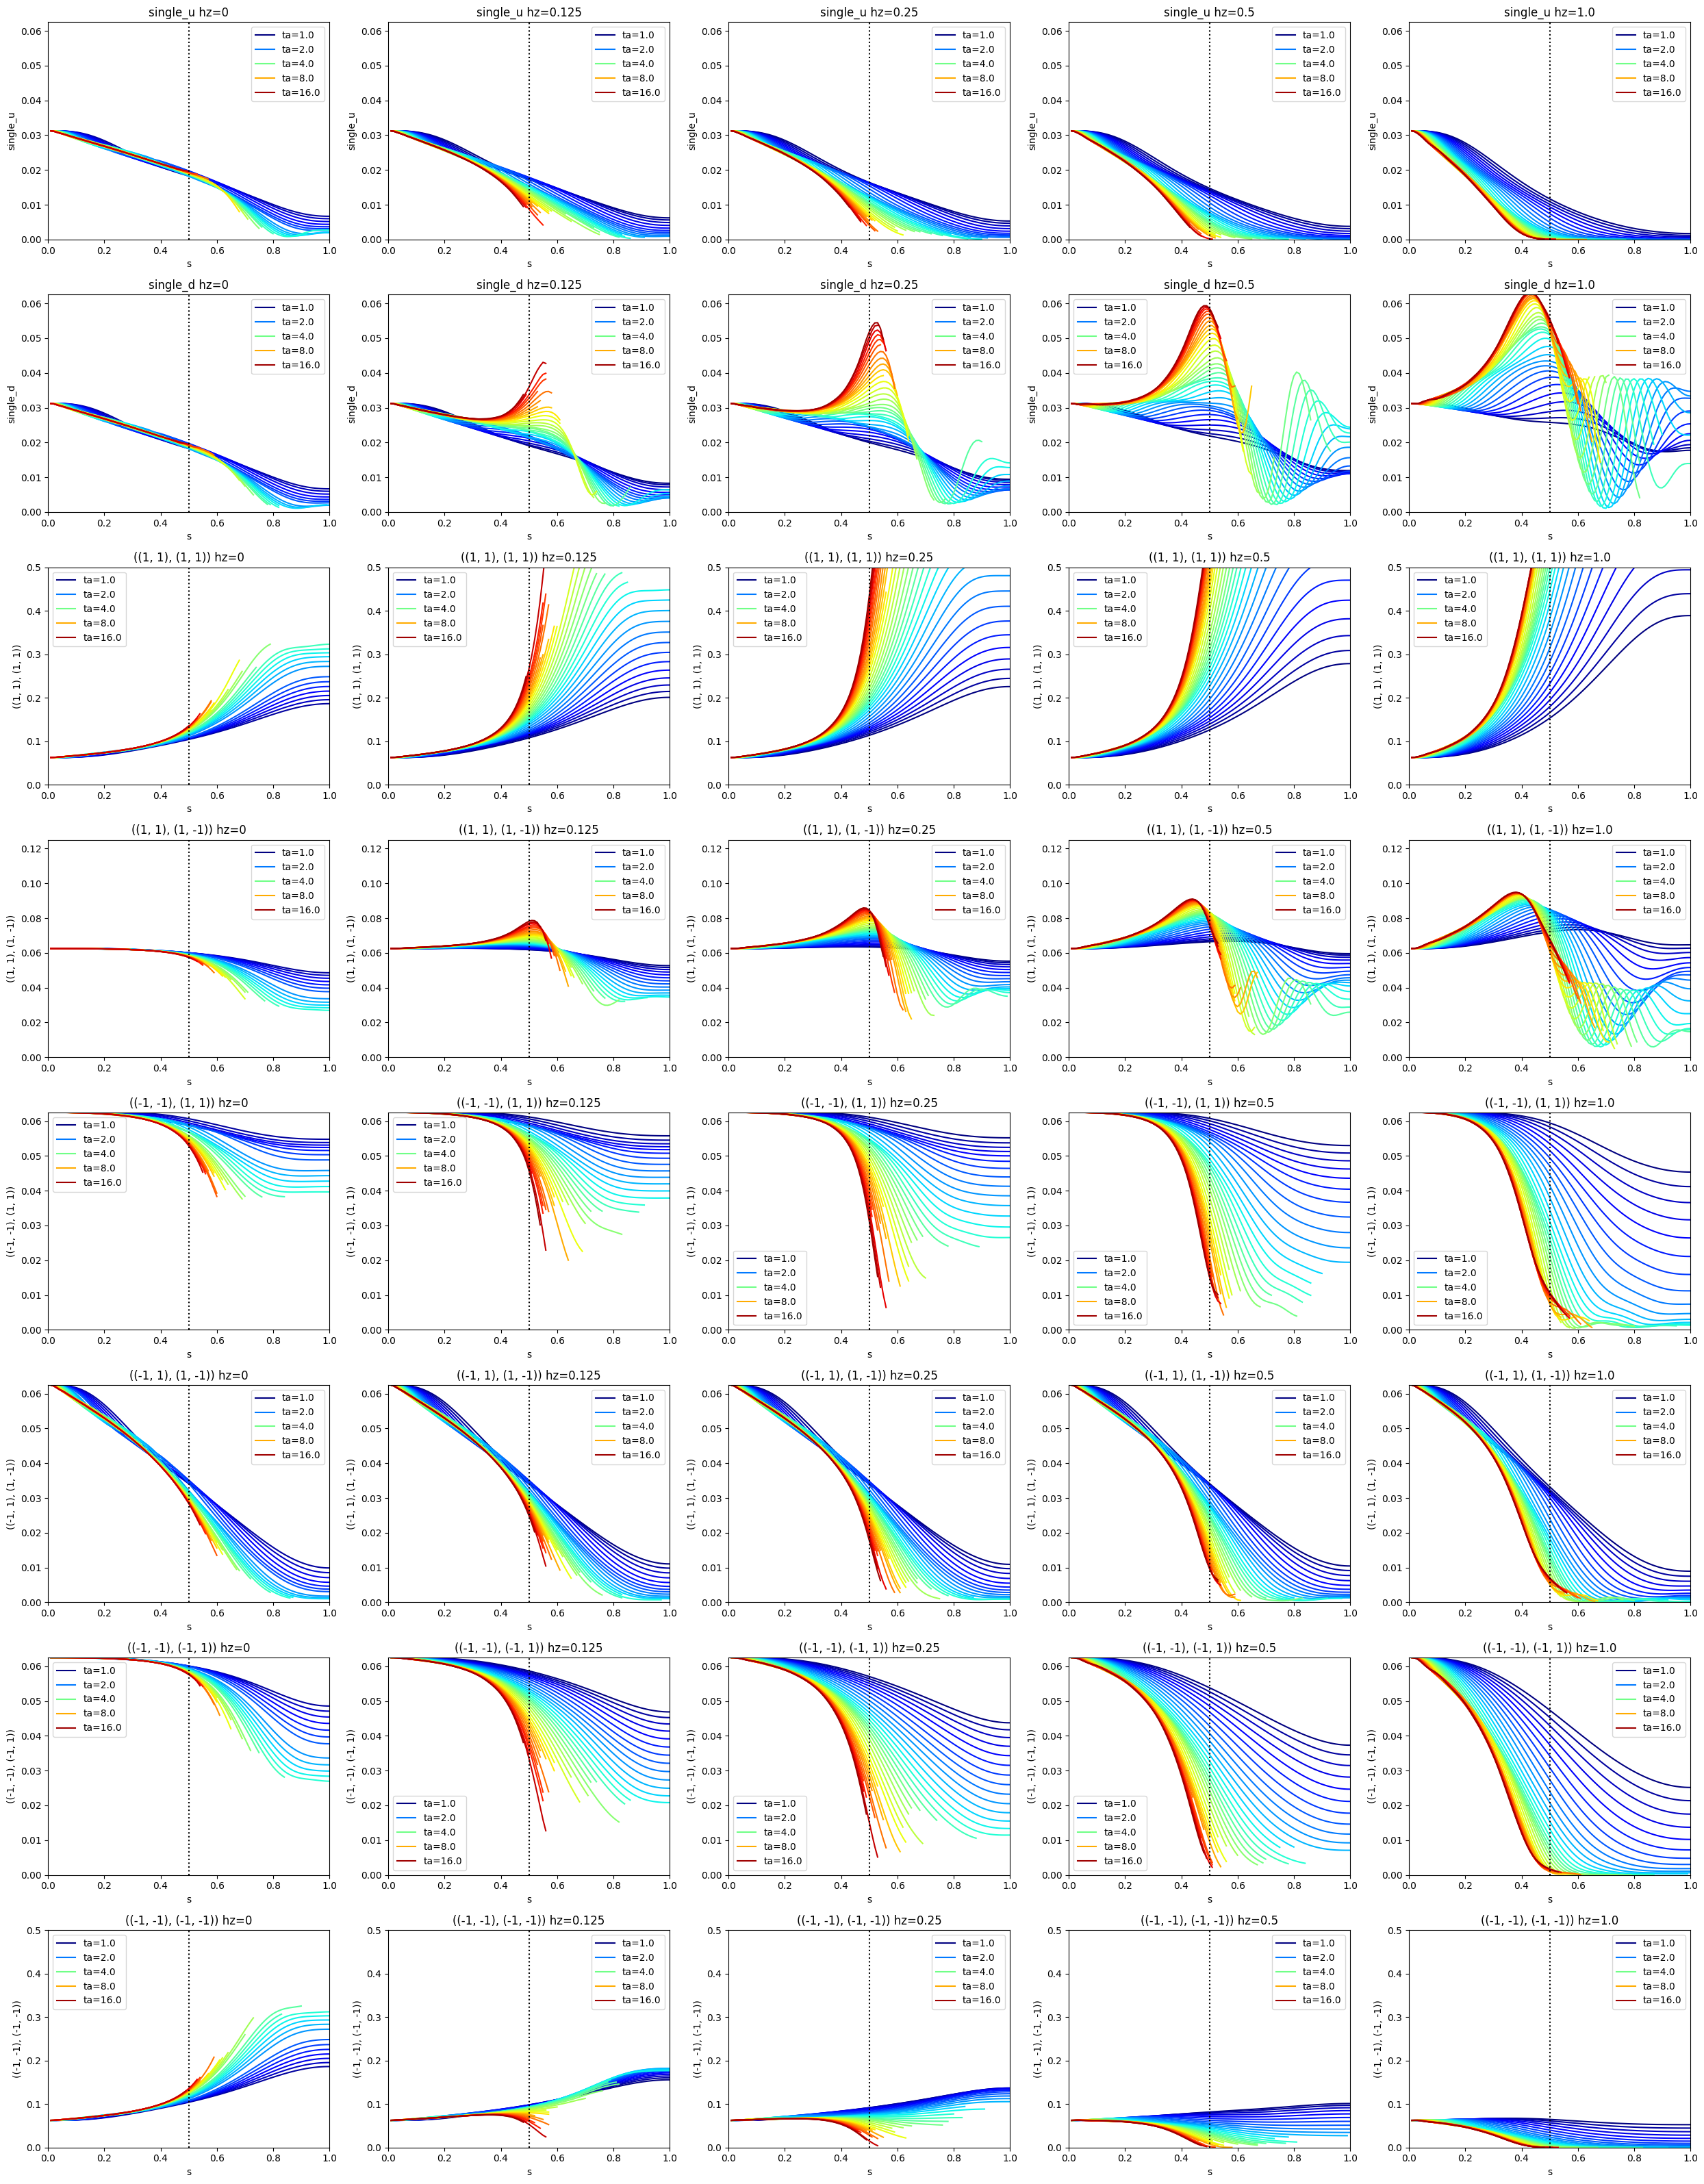

In [ ]:
fig, axs = plt.subplots(8, 5)
fig.set_size_inches(25, 32)

yls = [0.0625, 0.0625, 1.0, 0.125, 0.0625, 0.0625, 0.0625, 0.5]
for ii, val in enumerate(['single_u', 'single_d', ((1, 1), (1, 1)), ((1, 1), (1, -1)), ((-1, -1), (1, 1)), ((-1, 1), (1, -1)), ((-1, -1), (-1, 1)), ((-1, -1), (-1, -1))]):
    for jj, hz in enumerate([0, 0.125, 0.25, 0.5, 1.0]):
        plot_4point(axs[ii,jj], hz=hz, E=-2, D=8, val=val, in_g=False)
        axs[ii,jj].legend()
        axs[ii,jj].set_title(f"{val} {hz=}")
        axs[ii,jj].set_ylim([0, yls[ii]])
fig.tight_layout()

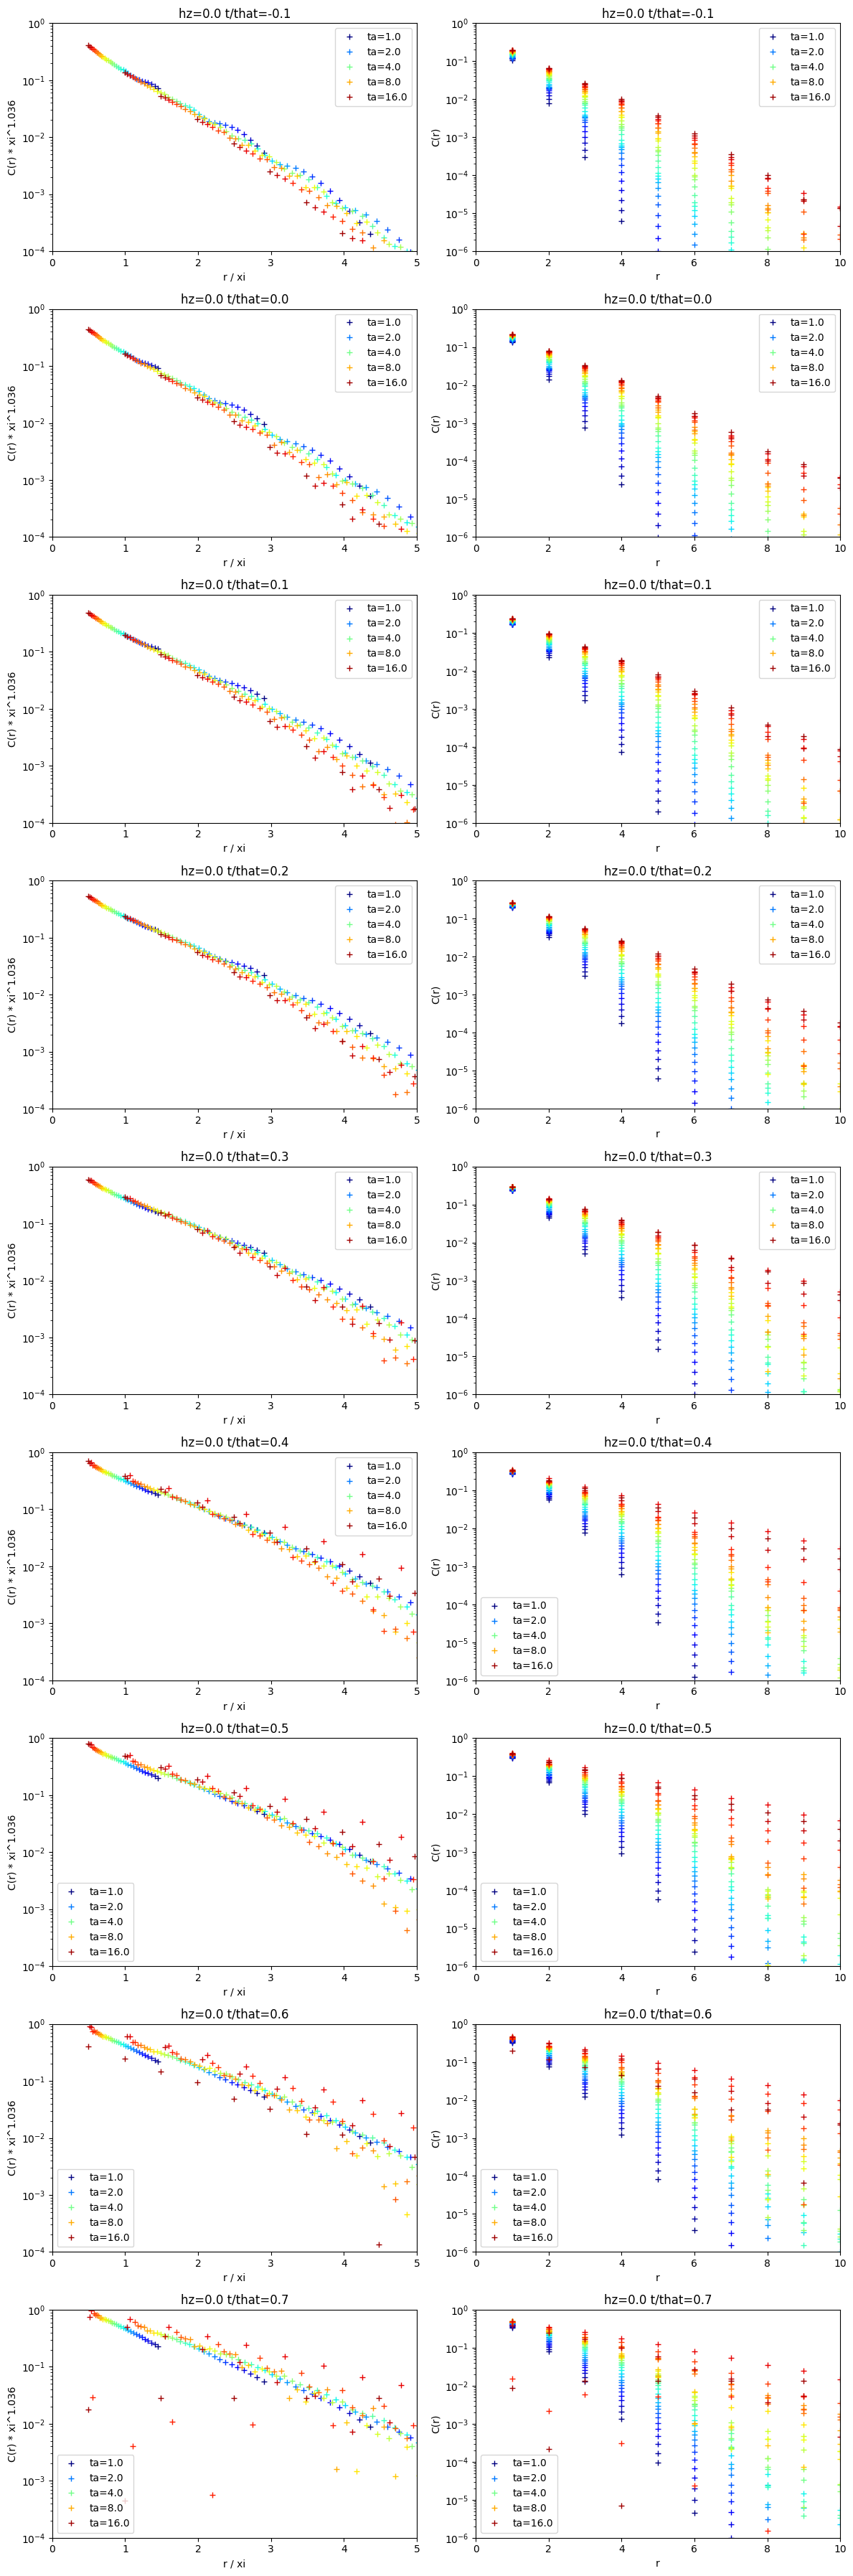

In [18]:
fig, axs = plt.subplots(9, 2)
fig.set_size_inches(12, 36)

for ii, tt in enumerate([-0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]):
    for jj, rescale in enumerate([True, False]):
        plot_zz(axs[ii, jj], tt=tt, rescale=rescale)

#axs[0, 0].legend()

fig.tight_layout()

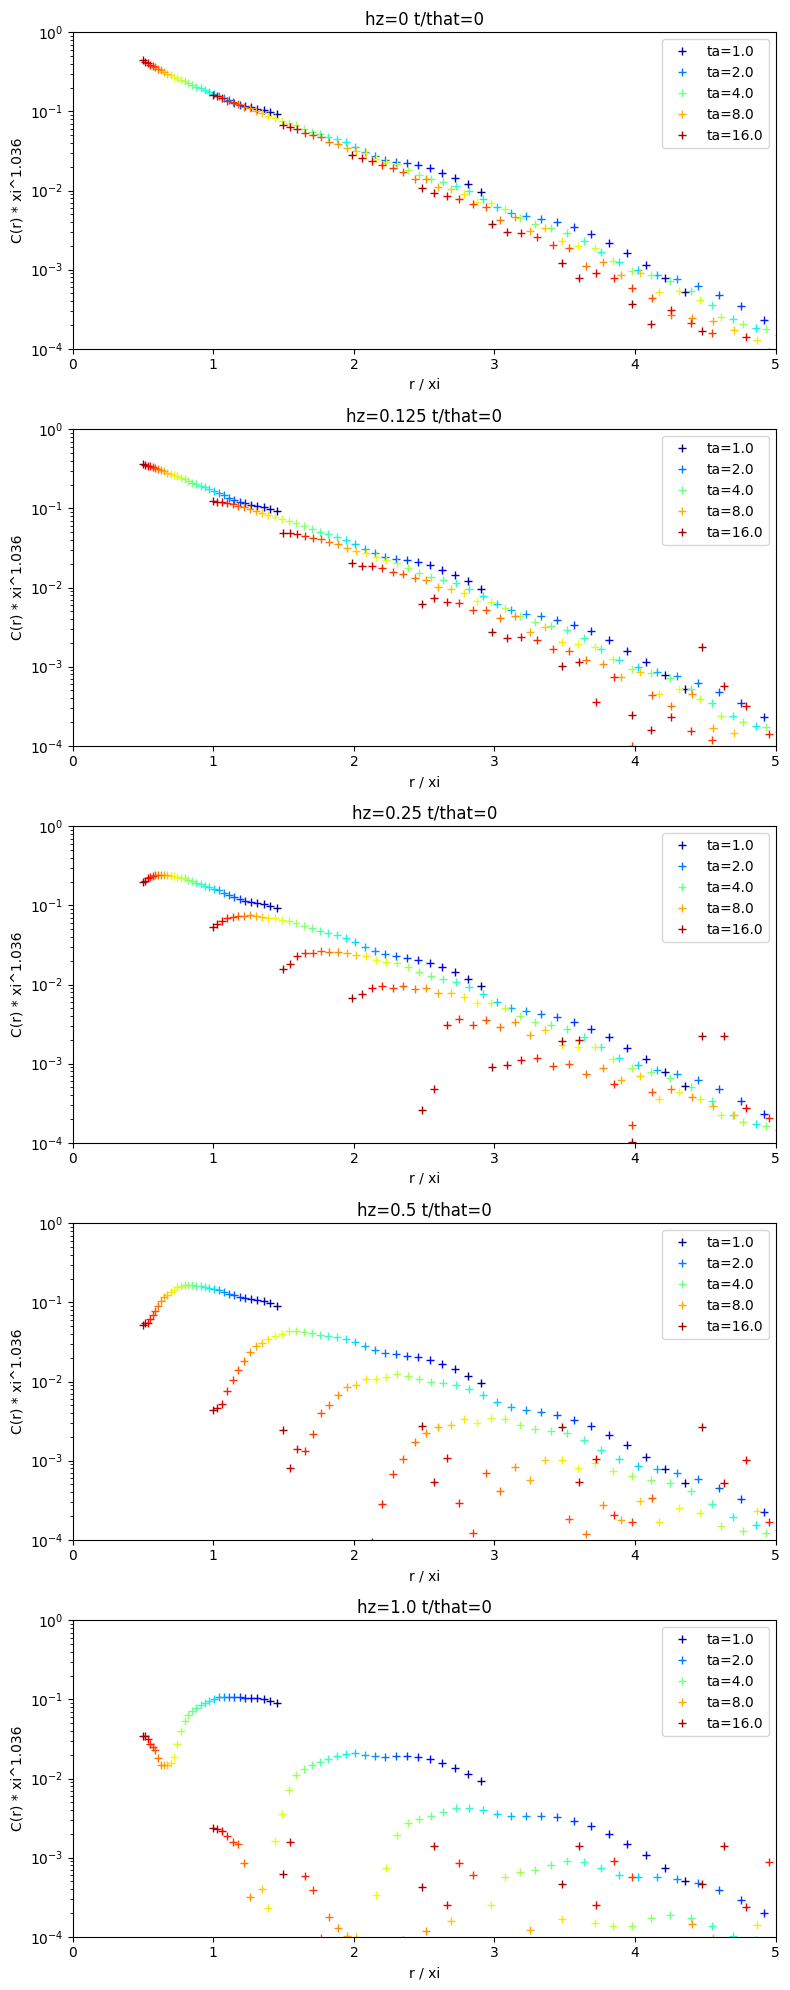

In [19]:
fig, axs = plt.subplots(5, 1, squeeze=False)
fig.set_size_inches(8, 20)

jj=0
for ii, hz in enumerate([0, 0.125, 0.25, 0.5, 1.0]):
    plot_zz(axs[ii, jj], hz=hz, tt=0, rescale=True)

#axs[0, 0].legend()

fig.tight_layout()

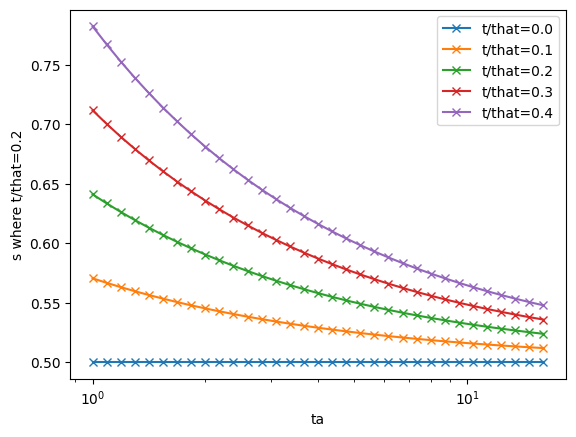

In [20]:
for tt in [0.0, 0.1, 0.2, 0.3, 0.4]:
    tas = [float(f"{x:0.4f}") for x in 2 ** np.linspace(0, 4, 33)]
    s02 = [0.5 + tt * (0.38054690140 * ta) ** 0.36 / ta for ta in tas]
    plt.semilogx(tas, s02, '-x', label=f"t/that={tt}")
plt.xlabel("ta")
plt.ylabel("s where t/that=0.2")
plt.legend()

In [21]:
from scipy.optimize import curve_fit

In [22]:
def func(x, a, b):
    return a * np.exp(-x / b)

(0.001, 1.0)

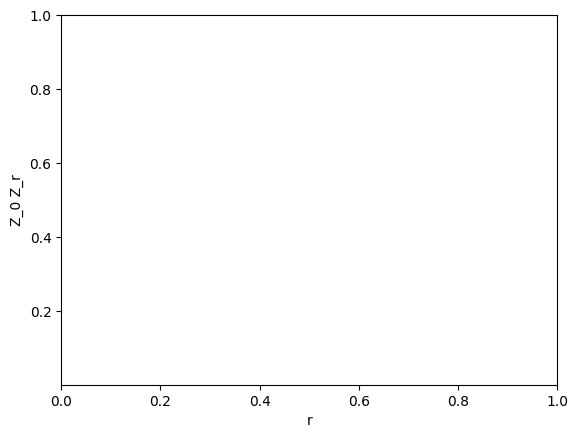

In [23]:
cm = sns.color_palette("tab20")
E = 0.5
hzs = [0.0, 0.125, 0.25, 0.5, 1.0]
tas = [ 0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 5.4, ]  #
#tas = [1.0, 2.0, 4.0, 5.4]
sfs = [0.3445, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48]

xis = {}
dis = {}
for sf in sfs:
    for hz in hzs:
        for i, ta in enumerate(tas):
            try:
                ind = (hz, ta, E, sf, 'ZZ')
                v = data_zz[ind]
                xx = np.arange(20) + 1

                yy = v
                # yy = np.array([1] + list(v))
                # xx = np.array([0] + list(xx))

                yy = np.abs(np.array(yy) - v[-1])


                ymin = np.mean(yy[10:])
                ii = (yy > 10 * ymin)
                plt.semilogy(xx[ii], yy[ii], '-x', color=cm[i], label=f"ta={ta}")
                popt, pcov = curve_fit(func, xx[ii], yy[ii])
                xis[hz, ta, sf] = popt[1]
                dis[hz, ta, sf] = popt[0]
            except:
                pass
#plt.legend()
plt.xlabel('r')
plt.ylabel('Z_0 Z_r')
plt.ylim([1e-3, 1])

In [24]:
popt

NameError: name 'popt' is not defined

Text(0, 0.5, 'correlation length')

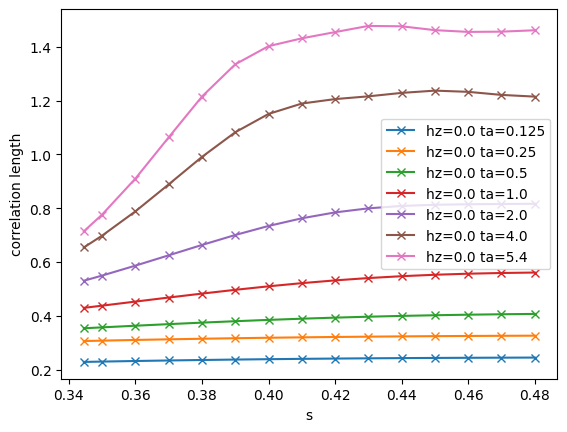

In [ ]:
hzs = [0.0] #, 0.125, 0.25, 0.5, 1.0]
for hz in hzs:
    for ta in tas:
        kk = [xis[hz, ta, sf] for sf in sfs if (hz, ta, sf) in xis]
        ss = [sf for sf in sfs if (hz, ta, sf) in xis]
        plt.plot(ss, kk, '-x', label=f'{hz=} {ta=}')

plt.legend()
plt.xlabel("s")
plt.ylabel("correlation length")


Text(0, 0.5, 'Czz prefactor')

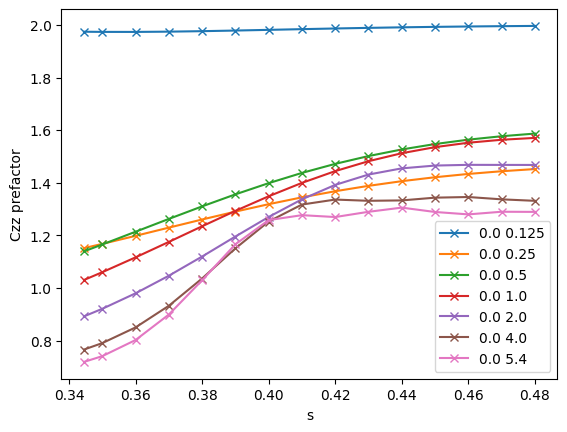

In [ ]:
for hz in hzs:
    for ta in tas:
        kk = [dis[hz, ta, sf] for sf in sfs if (hz, ta, sf) in dis]
        ss = [sf for sf in sfs if (hz, ta, sf) in xis]
        plt.plot(ss, kk, '-x', label=f'{hz} {ta}')

plt.legend()
plt.xlabel("s")
plt.ylabel("Czz prefactor")


In [ ]:
ll

[np.float64(0.125),
 np.float64(0.25),
 np.float64(0.5),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(4.0),
 np.float64(5.4)]

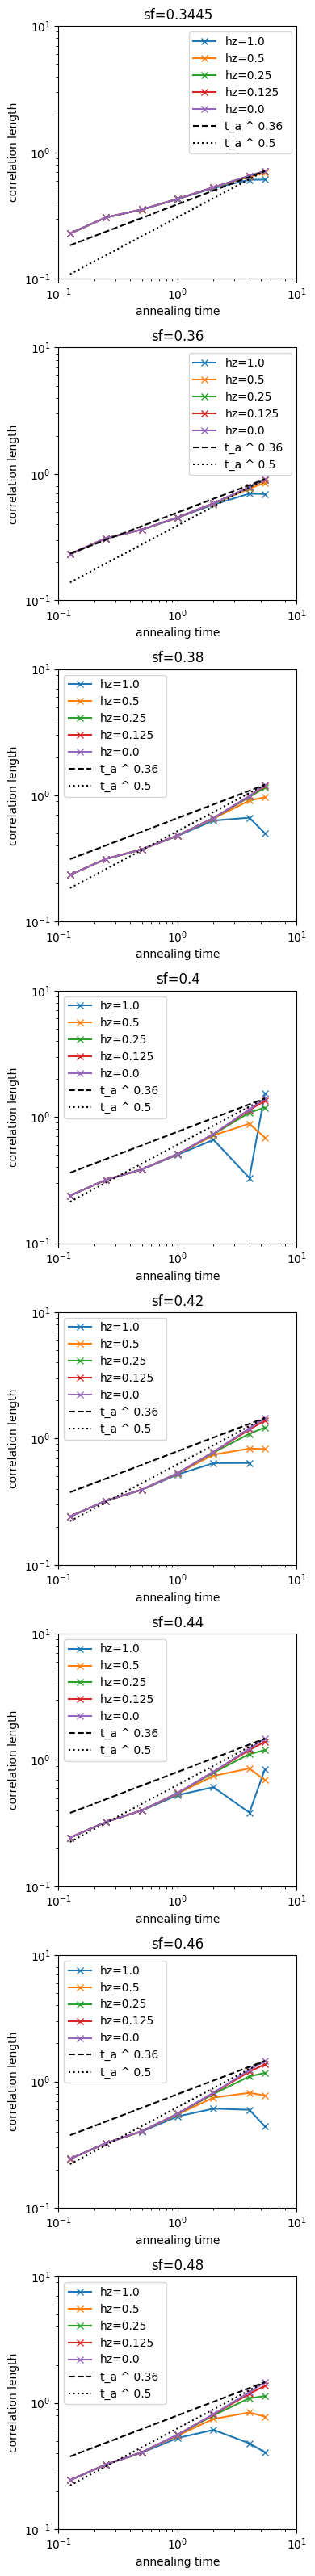

In [ ]:
hzs = [0.0, 0.125, 0.25, 0.5, 1.0]

fig, axs = plt.subplots(8, 1)
fig.set_size_inches(4, 32)

sf = sfs[0]
tas = np.array(tas)


for ii, sf in enumerate(sfs[::2]):
    for hz in hzs[::-1]:

        kk = [xis[hz, ta, sf] for ta in tas if (hz, ta, sf) in xis]
        ll = [ta for ta in tas if (hz, ta, sf) in xis]

        axs[ii].loglog(ll, kk, '-x', label=f'{hz=}')

    axs[ii].loglog(tas, kk[-1] * (tas / tas[-1]) ** 0.36, '--k', label="t_a ^ 0.36 ")
    axs[ii].loglog(tas, kk[-1] * (tas / tas[-1]) ** 0.50, ':k', label="t_a ^ 0.5 ")
    axs[ii].legend()
    axs[ii].set_xlim(0.1, 10)
    axs[ii].set_ylim(0.1, 10)
    axs[ii].set_xlabel('annealing time')
    axs[ii].set_ylabel('correlation length')
    axs[ii].set_title(f"{sf=}")

fig.tight_layout()

In [ ]:
len(sfs)

15